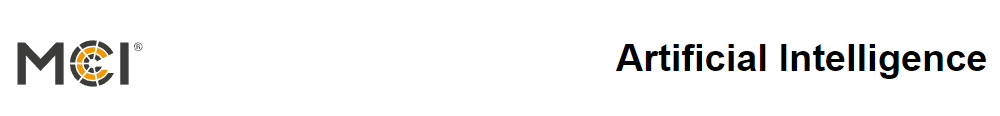

---

# 01 A Selftest Clustering k-Means Solution

Cluster the Data of Michael von Gerwen into several Clusters.

### 1.1. The Problem & Data Aquisition

Data is available as a numpy array in the numpy array (Michael_van_Gerwen.npy)

#### TASK: Import the relevant Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#### TASK: Load the Data

In [ ]:
van_Gerwen_data=np.load('../Data/Darts/Michael_van_Gerwen.npy')
print(van_Gerwen_data.shape)
np.random.shuffle(van_Gerwen_data)

(1439, 2)


# 1.2. Processing and Analysis

#### TASK Show the distribution of the data of Michael van Gerwen in a polar plot

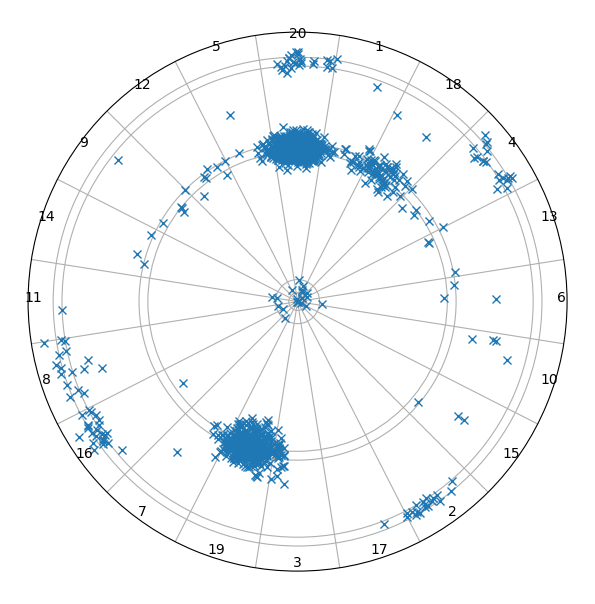

In [ ]:
fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
fig.set_size_inches((7,7))

axi.plot(van_Gerwen_data[:,1], van_Gerwen_data[:,0],'x')

# the 5,20,1 etc. field grids
axi.set_thetagrids(list(range(9,369,18)),
         [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
         , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
        , verticalalignment='center'
        , horizontalalignment = 'center')
# the proportions radius of inners and outer circle

numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

for index in range(len(numbers_score)):
    plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

rad = np.linspace(0, 6+11/16+1/4, 21)
azm = np.linspace(0, 2 * np.pi, 21)
axi.set_rgrids([0.1, 1.8])

# radius, r fields outer and inner bullseye
axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
axi.set_theta_zero_location("N",offset=0.0)
axi.set_yticklabels([])
radius, theta = np.meshgrid(rad, azm)

# 1.3 Develop the Algorithm for Clustering

#### TASK: Find the Clusters. Try to choose an appropriate number of Clusters

In [ ]:
K=9

#### TASK: With your chosen number of clusters, try to find the respective centroids (like we have done in class) 

In [ ]:
# This is our fallback option. If our algorithm takes too many iterations it might be caught in an endless loop.
# So we limit the maximum number of iterations
max_iterations = 20

def update_clusters(centroids, data):
    """ This function computes the updated clusters, precisely the index of the cluster for every data point.
    Parameters:
      centroids: array of K centroids, i.e. for K=1: [(x1,y1), (x2,y2)]
      data: array of N data points, i.e. [(x1,y1), ..., (xN,yN)]
    Returns:
      array of N cluster indices, indicating the cluster per data point, i.e. [i1, i2, i3, ..., iN]
      0 <= cluster_index < K, i.e. for K=2 the result might look like [0,1,0,0,1,1,0,0,0,...,1] of size N.
      This would mean that the first point within data corresponds to cluster0, the second to cluster1, and so on.
    Hints:
      To compute the distance between a centroid and data points use np.linalg.norm().
      Ideally, use a vectorized implementation instead of computing every distance one by one.
      To find the minimum distance np.argmin might be helpful.
      Use the axis argument of numpy functions.
    """
    # First, compute the distance of every point to the K (=2) centroids using np.linalg.norm
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])

    # Then, set the indices by finding the minimum distance
    cluster_indices = np.argmin(distances, axis=0)

    # Return the result
    return cluster_indices


def compute_means(cluster_indices, data):
    """ This function computes the new centroids (i.e. means) for each cluster. To do so the samples from data with
    the same cluster index
    Parameters:
      cluster_indices: array of N cluster indices, indicating the cluster per data point, i.e. [i1, i2, i3, ..., iN]
      data: array of N data points, i.e. [(x1,y1), ..., (xN,yN)]
    Returns:
      array of K centroids, i.e. for K=3: [(x1,y1), (x2,y2), (x3,y3)]
    Hints:
      Use the axis argument of numpy functions.
    """
    # compute the mean per cluster
    means = np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

    # return the result
    return means


# choose initial centroids not randomly
centroids = np.array([[17.5/4,162/360*(2*np.pi)],[17.5/4,0/360*(2*np.pi)],[17.5/4,328/360*(2*np.pi)],[6+11/16+1/8,0/360*(2*np.pi)],[6+11/16+1/8,122/360*(2*np.pi)],[6+11/16+1/8,106/360*(2*np.pi)],[6+11/16+1/8,306/360*(2*np.pi)],[6+11/16+1/8,212/360*(2*np.pi)],[0,0]])

# loop until
# a) convergence (centroids did not change), or
# b) max_iterations reached
for i in range(max_iterations):
    print(centroids)

    # create clusters by assigning points to the closest centroid (update_clusters)
    cluster_indices = update_clusters(centroids, van_Gerwen_data)

    # save previous centroids to check with new centroids
    previous_centroids = centroids

    # update centroids by computing the mean of the clusters (compute_means)
    centroids = compute_means(cluster_indices, van_Gerwen_data)

    # check if centroids changed - if not: exit the loop (Hint: use the break statement)
    diff = previous_centroids - centroids
    if not diff.any():
        break

[[4.375      2.82743339]
 [4.375      0.        ]
 [4.375      5.72467995]
 [6.8125     0.        ]
 [6.8125     2.12930169]
 [6.8125     1.85004901]
 [6.8125     5.34070751]
 [6.8125     3.70009801]
 [0.         0.        ]]
[[ 4.34082605  2.82434798]
 [ 4.37198338 -0.00715258]
 [ 4.36797033  5.72314802]
 [ 6.53471605 -0.42848392]
 [ 6.79956288  2.14439449]
 [ 6.79556848  1.83311677]
 [ 6.78129472  5.3222743 ]
 [ 6.81356555  3.69688168]
 [ 0.37226519  0.16036896]]
[[ 4.34082605e+00  2.82434798e+00]
 [ 4.37114181e+00 -3.31721745e-03]
 [ 4.36797033e+00  5.72314802e+00]
 [ 6.49847891e+00 -5.40887654e-01]
 [ 6.79956288e+00  2.14439449e+00]
 [ 6.77742034e+00  1.77826153e+00]
 [ 6.78129472e+00  5.32227430e+00]
 [ 6.81356555e+00  3.69688168e+00]
 [ 3.72265186e-01  1.60368959e-01]]
[[ 4.34082605e+00  2.82434798e+00]
 [ 4.37114181e+00 -3.31721745e-03]
 [ 4.36797033e+00  5.72314802e+00]
 [ 6.49847891e+00 -5.40887654e-01]
 [ 6.79917621e+00  2.13054176e+00]
 [ 6.77511245e+00  1.75253169e+00]
 [ 6

#### TASK: Visualize the process like it has been done in class

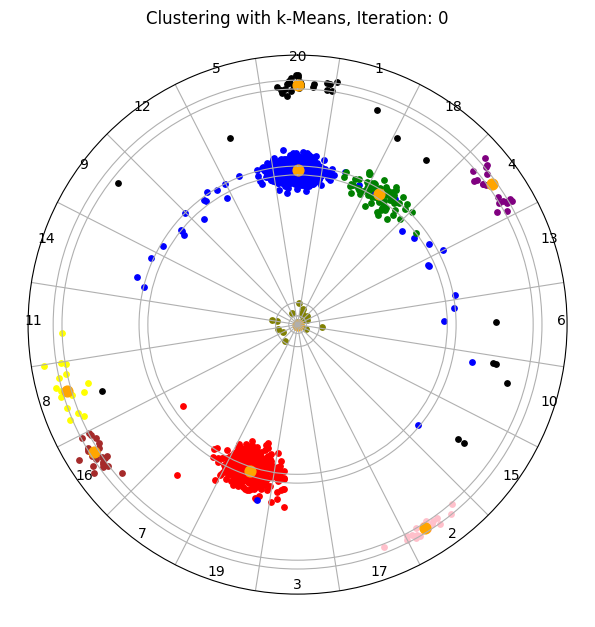

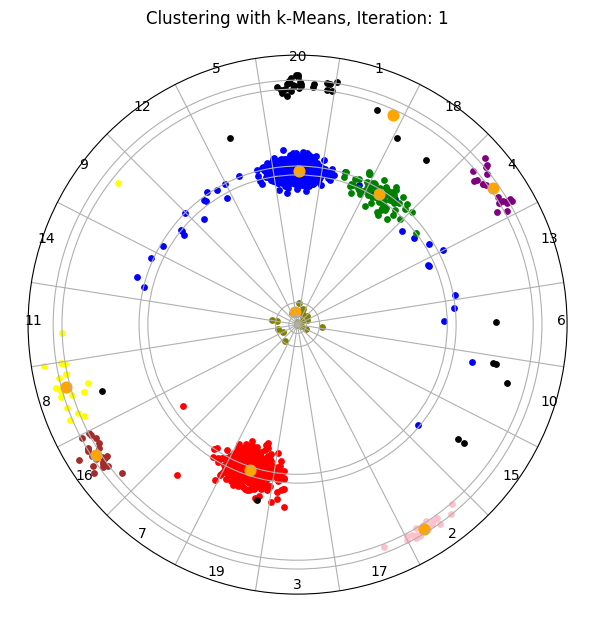

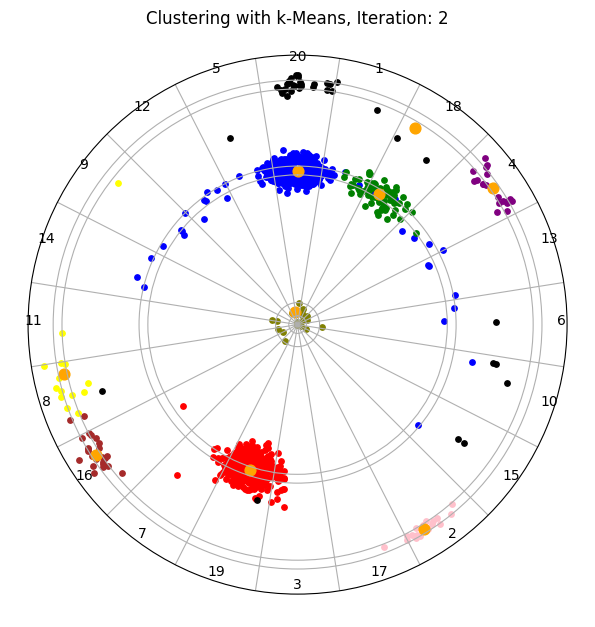

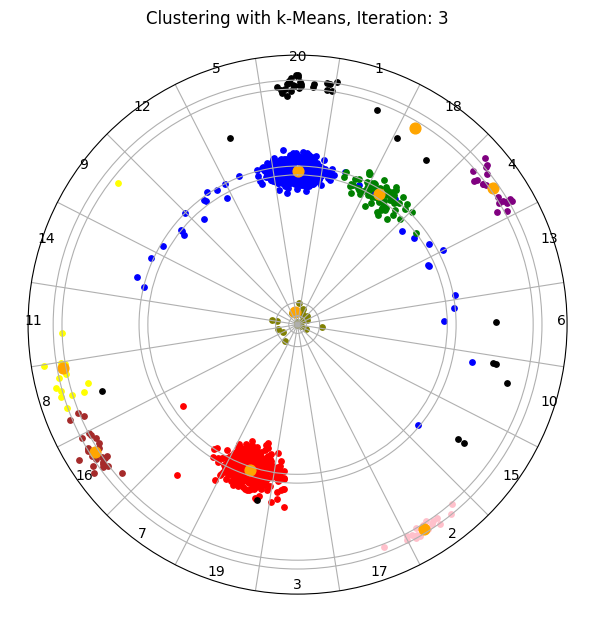

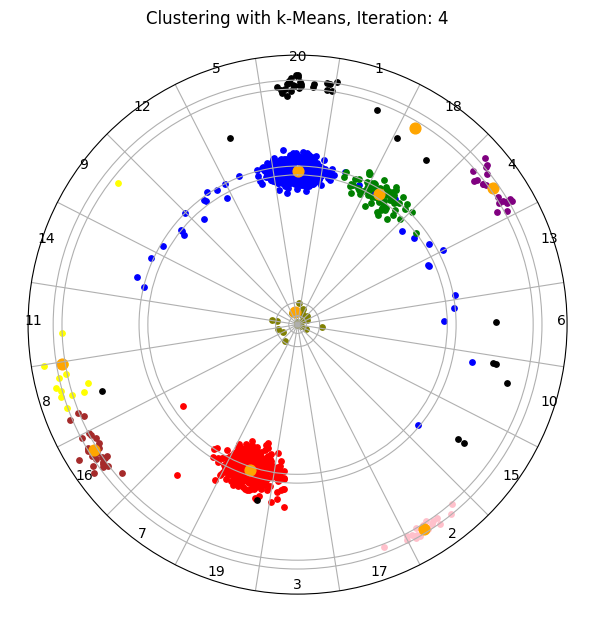

In [ ]:
max_iterations = 20

def update_clusters(centroids, data):
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])
    return np.argmin(distances, axis=0)

def compute_means(cluster_indices, data):
    return np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

# choose initial centroids not randomly
centroids = np.array([[17.5/4,162/360*(2*np.pi)],[17.5/4,0/360*(2*np.pi)],[17.5/4,328/360*(2*np.pi)],[6+11/16+1/8,0/360*(2*np.pi)],[6+11/16+1/8,122/360*(2*np.pi)],[6+11/16+1/8,106/360*(2*np.pi)],[6+11/16+1/8,306/360*(2*np.pi)],[6+11/16+1/8,212/360*(2*np.pi)],[0,0]])

for i in range(max_iterations):
    cluster_indices = update_clusters(centroids, van_Gerwen_data)

    if np.mod(i,1)==0:
        fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
        fig.set_size_inches((7,7))

        axi.scatter(van_Gerwen_data[cluster_indices==0,1], van_Gerwen_data[cluster_indices==0,0], color="red", s=15, label="Cluster0")
        axi.scatter(van_Gerwen_data[cluster_indices==1,1], van_Gerwen_data[cluster_indices==1,0], color="blue", s=15, label="Cluster1")
        axi.scatter(van_Gerwen_data[cluster_indices==2,1], van_Gerwen_data[cluster_indices==2,0], color="green", s=15, label="Cluster2")
        axi.scatter(van_Gerwen_data[cluster_indices==3,1], van_Gerwen_data[cluster_indices==3,0], color="black", s=15, label="Cluster3")
        axi.scatter(van_Gerwen_data[cluster_indices==4,1], van_Gerwen_data[cluster_indices==4,0], color="brown", s=15, label="Cluster4")
        axi.scatter(van_Gerwen_data[cluster_indices==5,1], van_Gerwen_data[cluster_indices==5,0], color="yellow", s=15, label="Cluster5")
        axi.scatter(van_Gerwen_data[cluster_indices==6,1], van_Gerwen_data[cluster_indices==6,0], color="purple", s=15, label="Cluster6")
        axi.scatter(van_Gerwen_data[cluster_indices==7,1], van_Gerwen_data[cluster_indices==7,0], color="pink", s=15, label="Cluster7")
        axi.scatter(van_Gerwen_data[cluster_indices==8,1], van_Gerwen_data[cluster_indices==8,0], color="olive", s=15, label="Cluster8")

        axi.scatter(centroids[:,1],centroids[:,0], color="orange", s=60, label="centroids")
        plt.title("Clustering with k-Means, Iteration: "+str(i))

        # the 5,20,1 etc. field grids
        axi.set_thetagrids(list(range(9,369,18)),
             [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
            , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
            , verticalalignment='center'
            , horizontalalignment = 'center')
        # the proportions radius of inners and outer circle

        numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

        for index in range(len(numbers_score)):
            plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

        rad = np.linspace(0, 6+11/16+1/4, 21)
        azm = np.linspace(0, 2 * np.pi, 21)
        axi.set_rgrids([0.1, 1.8])

        # radius, r fields outer and inner bullseye
        axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
        axi.set_theta_zero_location("N",offset=0.0)
        axi.set_yticklabels([])
        radius, theta = np.meshgrid(rad, azm)

    previous_centroids = centroids
    centroids = compute_means(cluster_indices, van_Gerwen_data)
    diff = previous_centroids - centroids
    if not diff.any():
        break

By finding the centroids we also see, that the plyers aimed for the triple 19 field and the triple 20 field.

As the plots with a polar shape are not that easy to grasp (humans are used to think in a classic cartesian coordinate system, not in polar coordinates), we do the same plot once more, but we use a classic cartesian coordinate system.

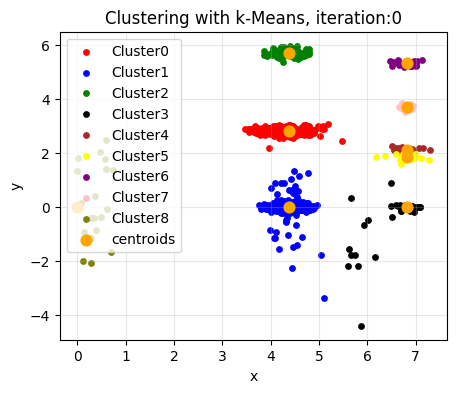

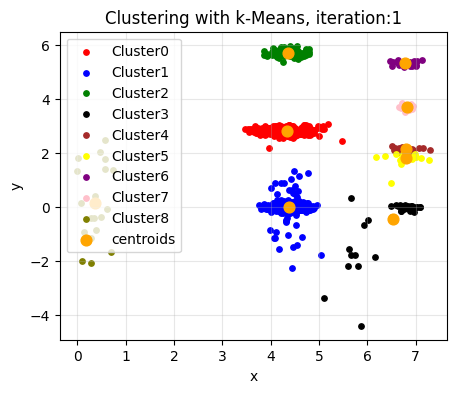

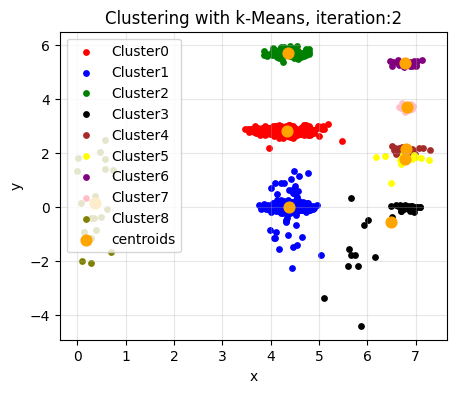

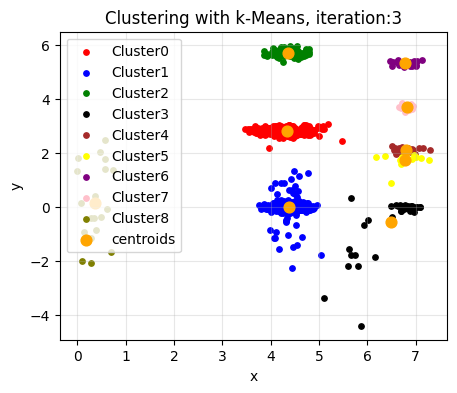

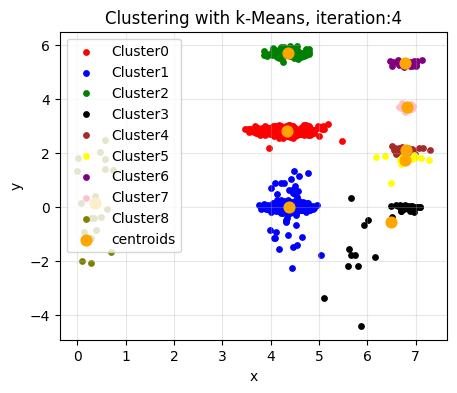

In [ ]:
max_iterations = 100

def update_clusters(centroids, data):
    distances = np.array([np.linalg.norm(centroids[k]-data, axis=1) for k in range(K)])
    return np.argmin(distances, axis=0)

def compute_means(cluster_indices, data):
    return np.array([np.mean(data[cluster_indices == k,:], axis=0) for k in range(K)])

centroids = np.array([[17.5/4,162/360*(2*np.pi)],[17.5/4,0/360*(2*np.pi)],[17.5/4,328/360*(2*np.pi)],[6+11/16+1/8,0/360*(2*np.pi)],[6+11/16+1/8,122/360*(2*np.pi)],[6+11/16+1/8,106/360*(2*np.pi)],[6+11/16+1/8,306/360*(2*np.pi)],[6+11/16+1/8,212/360*(2*np.pi)],[0,0]])

for i in range(max_iterations):
    cluster_indices = update_clusters(centroids, van_Gerwen_data)


    plt.figure(figsize=(5,4))
    plt.grid(alpha=0.3)
    plt.scatter(van_Gerwen_data[cluster_indices==0,0], van_Gerwen_data[cluster_indices==0,1], color="red", s=15, label="Cluster0")
    plt.scatter(van_Gerwen_data[cluster_indices==1,0], van_Gerwen_data[cluster_indices==1,1], color="blue", s=15, label="Cluster1")
    plt.scatter(van_Gerwen_data[cluster_indices==2,0], van_Gerwen_data[cluster_indices==2,1], color="green", s=15, label="Cluster2")
    plt.scatter(van_Gerwen_data[cluster_indices==3,0], van_Gerwen_data[cluster_indices==3,1], color="black", s=15, label="Cluster3")
    plt.scatter(van_Gerwen_data[cluster_indices==4,0], van_Gerwen_data[cluster_indices==4,1], color="brown", s=15, label="Cluster4")
    plt.scatter(van_Gerwen_data[cluster_indices==5,0], van_Gerwen_data[cluster_indices==5,1], color="yellow", s=15, label="Cluster5")
    plt.scatter(van_Gerwen_data[cluster_indices==6,0], van_Gerwen_data[cluster_indices==6,1], color="purple", s=15, label="Cluster6")
    plt.scatter(van_Gerwen_data[cluster_indices==7,0], van_Gerwen_data[cluster_indices==7,1], color="pink", s=15, label="Cluster7")
    plt.scatter(van_Gerwen_data[cluster_indices==8,0], van_Gerwen_data[cluster_indices==8,1], color="olive", s=15, label="Cluster8")
    plt.scatter(centroids[:,0],centroids[:,1], color="orange", s=60, label="centroids")
    plt.legend()
    plt.title("Clustering with k-Means, iteration:"+str(i))
    plt.xlabel("radius in inch")
    plt.ylabel("theta in rad")
    # plt.savefig("kMeans-result.png", bbox_inches='tight')



    previous_centroids = centroids
    centroids = compute_means(cluster_indices, van_Gerwen_data)
    diff = previous_centroids - centroids
    if not diff.any():
        break